In [1]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 1: Import các thư viện cần thiết
# Chúng ta sẽ import TensorFlow và các thành phần của Keras để xây dựng mô hình,
# NumPy để xử lý dữ liệu và Matplotlib để trực quan hóa kết quả.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

Kích thước tập huấn luyện (ảnh): (60000, 28, 28)
Kích thước tập huấn luyện (nhãn): (60000,)
Kích thước tập kiểm tra (ảnh): (10000, 28, 28)
Kích thước tập kiểm tra (nhãn): (10000,)


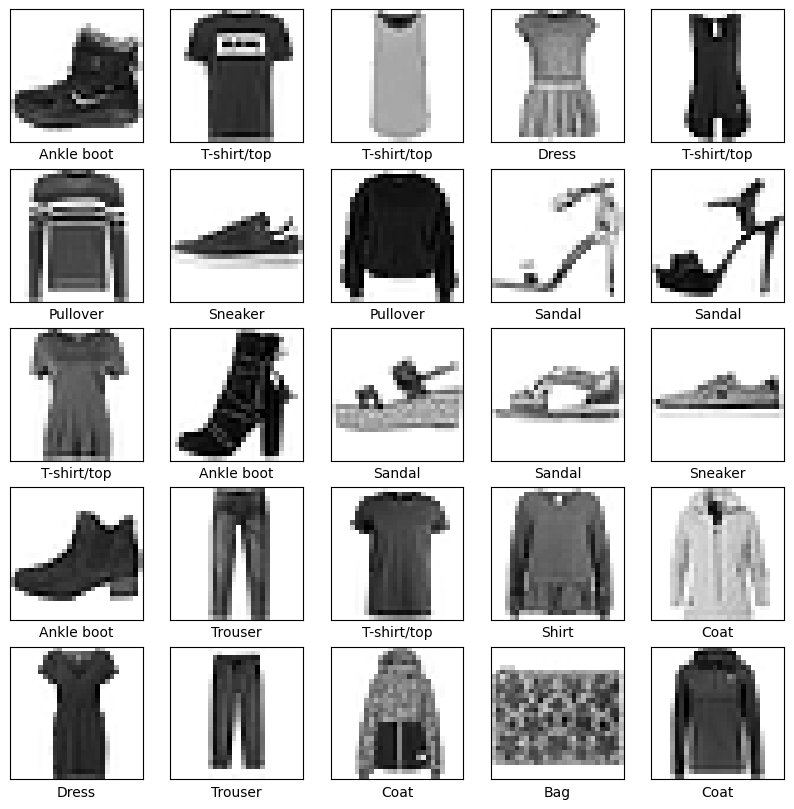

In [2]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 2: Tải và khám phá dữ liệu (Bước "Collect and Understand Data")
# Keras cung cấp sẵn bộ dữ liệu Fashion MNIST, gồm 70,000 ảnh thang độ xám (28x28 pixels)
# của 10 loại sản phẩm thời trang. Dữ liệu đã được chia sẵn thành tập train và test.
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

# In ra kích thước của các tập dữ liệu để hiểu cấu trúc
print(f"Kích thước tập huấn luyện (ảnh): {x_train_full.shape}")
print(f"Kích thước tập huấn luyện (nhãn): {y_train_full.shape}")
print(f"Kích thước tập kiểm tra (ảnh): {x_test.shape}")
print(f"Kích thước tập kiểm tra (nhãn): {y_test.shape}")

# Định nghĩa tên các lớp để hiển thị cho dễ hiểu
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Hiển thị một vài ảnh mẫu
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train_full[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train_full[i]])
plt.show()

In [3]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 3: Chuẩn bị dữ liệu (Bước "Prepare the Data")
# 1. Chuẩn hóa giá trị (Value Normalization): Chuyển giá trị pixel từ 0-255 về 0-1
#    để giúp mô hình học tốt hơn.
# 2. Vector hóa nhãn (Label Vectorization): Chuyển nhãn từ dạng số (0-9) sang dạng one-hot encoding.
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Chuyển đổi nhãn sang dạng one-hot
num_classes = 10
y_train_full = keras.utils.to_categorical(y_train_full, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [4]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 4: Chọn phương thức đánh giá (Bước "Choose an Evaluation Protocol")
# Chúng ta sẽ sử dụng phương pháp "hold-out validation".
# Ta tách 10,000 ảnh từ tập huấn luyện ban đầu để làm tập validation.
# Tập validation dùng để theo dõi hiệu suất và tinh chỉnh mô hình trong quá trình huấn luyện.
x_val = x_train_full[:10000]
y_val = y_train_full[:10000]

x_train = x_train_full[10000:]
y_train = y_train_full[10000:]

print(f"Kích thước tập huấn luyện mới: {x_train.shape}")
print(f"Kích thước tập validation: {x_val.shape}")

Kích thước tập huấn luyện mới: (50000, 28, 28)
Kích thước tập validation: (10000, 28, 28)


In [5]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 5: Xây dựng mô hình có khả năng Overfitting (Bước "Scale Up")
# Để tạo ra đường cong huấn luyện đẹp, ta sẽ xây dựng một mô hình đủ lớn và phức tạp.
# Mô hình gồm:
# - Lớp Flatten: Chuyển ảnh 28x28 thành vector 784 chiều.
# - 2 lớp Dense (fully-connected) với hàm kích hoạt 'relu'.
# - Lớp Dropout: Một kỹ thuật điều chuẩn hóa (regularization) sẽ được thêm ở bước sau,
#   nhưng ta xây dựng kiến trúc trước.
# - Lớp đầu ra (output layer) với 10 units và hàm 'softmax' cho bài toán phân loại đa lớp.
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 6: Biên dịch mô hình (Compile the model)
# Ở bước này, ta cấu hình quá trình học cho mô hình:
# - Optimizer: 'adam' là một lựa chọn phổ biến và hiệu quả.
# - Loss function: 'categorical_crossentropy' phù hợp cho bài toán phân loại đa lớp với nhãn one-hot.
# - Metrics: Theo dõi 'accuracy' (độ chính xác) trong quá trình huấn luyện.
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 7: Huấn luyện mô hình (Train the model)
# Ta sẽ huấn luyện mô hình trong 30 epochs. Số epochs đủ lớn để mô hình có thể học
# và sau đó bắt đầu overfitting, tạo ra đường cong như yêu cầu.
# Lịch sử huấn luyện (loss và accuracy trên các tập train/validation) sẽ được lưu lại.
epochs = 30
history = model.fit(x_train, y_train,
                    epochs=epochs,
                    batch_size=128,
                    validation_data=(x_val, y_val))

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8110 - loss: 0.5349 - val_accuracy: 0.8474 - val_loss: 0.4155
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8621 - loss: 0.3859 - val_accuracy: 0.8551 - val_loss: 0.3885
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8762 - loss: 0.3414 - val_accuracy: 0.8771 - val_loss: 0.3345
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8846 - loss: 0.3125 - val_accuracy: 0.8671 - val_loss: 0.3526
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8919 - loss: 0.2943 - val_accuracy: 0.8748 - val_loss: 0.3313
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8980 - loss: 0.2754 - val_accuracy: 0.8748 - val_loss: 0.3418
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9019 - loss: 0.2636 - val_accuracy: 0.8849 - val_loss: 0.3025
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9050 - loss: 0.2559 - val_accuracy: 0.

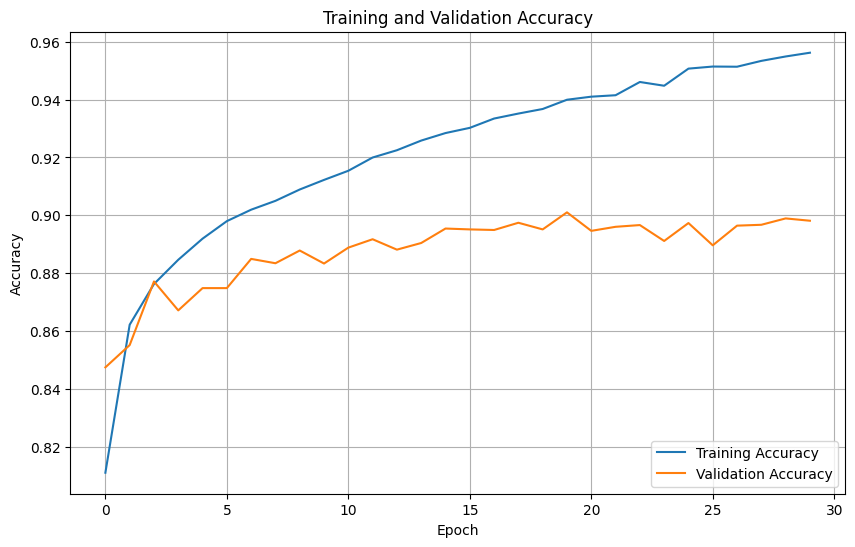

In [8]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 8: Trực quan hóa kết quả - Biểu đồ Accuracy
# Vẽ biểu đồ so sánh độ chính xác trên tập huấn luyện và tập validation qua các epochs.
# Đường cong accuracy trên tập validation đi ngang hoặc đi xuống trong khi
# accuracy trên tập train vẫn tăng là dấu hiệu của overfitting.
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

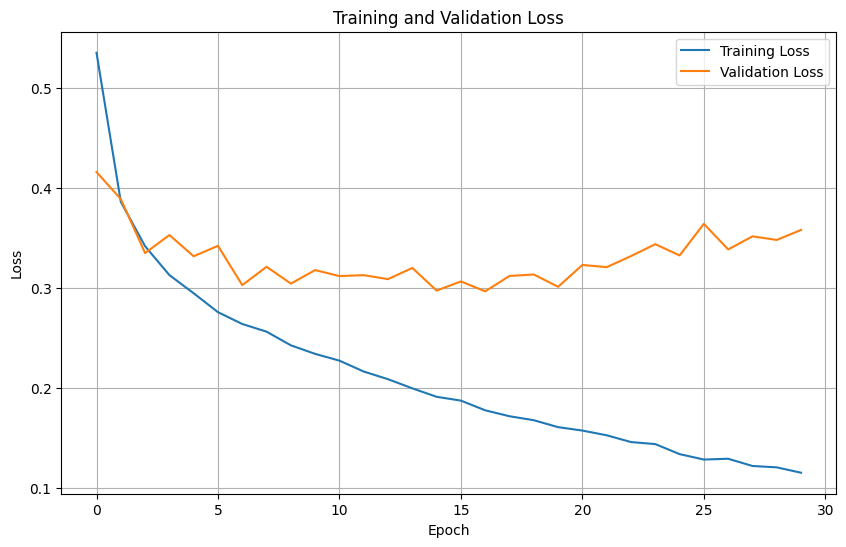

In [9]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 9: Trực quan hóa kết quả - Biểu đồ Loss
# Tương tự, vẽ biểu đồ so sánh hàm mất mát.
# Khi loss trên tập validation bắt đầu tăng lên trong khi loss trên tập train
# tiếp tục giảm, đó là một dấu hiệu rõ ràng của overfitting.
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


In [10]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 10: Đánh giá cuối cùng trên tập Test (Bước cuối của "Develop a Model")
# Sau khi đã hoàn tất huấn luyện và tinh chỉnh (nếu có), ta đánh giá hiệu suất cuối cùng
# của mô hình trên tập dữ liệu test - tập dữ liệu mà mô hình chưa bao giờ thấy.
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nĐộ chính xác trên tập test: {test_acc:.4f}')

313/313 - 0s - 957us/step - accuracy: 0.8904 - loss: 0.3965

Độ chính xác trên tập test: 0.8904


In [11]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 11 (Cập nhật): Áp dụng Regularization và Early Stopping
# Chúng ta sẽ thêm một kỹ thuật nữa để hoàn thiện quá trình huấn luyện:
# 3. Early Stopping: Kỹ thuật này sẽ theo dõi một chỉ số (thường là validation loss)
#    và dừng việc huấn luyện nếu chỉ số đó không cải thiện trong một số lượng epochs nhất định
#    (gọi là "patience"). Điều này giúp ta tìm được điểm dừng tối ưu, tránh lãng phí
#    thời gian tính toán và ngăn mô hình học thêm những thông tin nhiễu từ tập train.

from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping # Thêm import cho EarlyStopping

regularized_model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    
    layers.Dense(256,
                 activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),

    layers.Dense(128,
                 activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    
    layers.Dense(num_classes, activation='softmax')
])

# Biên dịch mô hình mới
regularized_model.compile(optimizer='adam',
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

# --- THÊM MỚI: Cấu hình Early Stopping callback ---
# - monitor='val_loss': Theo dõi loss trên tập validation.
# - patience=5: Dừng lại nếu val_loss không cải thiện trong 5 epochs liên tiếp.
# - restore_best_weights=True: Khôi phục lại trọng số của mô hình từ epoch tốt nhất.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Huấn luyện mô hình với Early Stopping
# Ta vẫn đặt epochs là 30, nhưng EarlyStopping có thể sẽ dừng quá trình huấn luyện sớm hơn.
history_regularized = regularized_model.fit(x_train, y_train,
                                            epochs=epochs,
                                            batch_size=128,
                                            validation_data=(x_val, y_val),
                                            callbacks=[early_stopping]) # Thêm callback vào quá trình huấn luyện

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7223 - loss: 1.1539 - val_accuracy: 0.8304 - val_loss: 0.7471
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8117 - loss: 0.7746 - val_accuracy: 0.8464 - val_loss: 0.6285
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8236 - loss: 0.6819 - val_accuracy: 0.8491 - val_loss: 0.5834
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8289 - loss: 0.6352 - val_accuracy: 0.8491 - val_loss: 0.5415
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8311 - loss: 0.6108 - val_accuracy: 0.8561 - val_loss: 0.5243
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8347 - loss: 0.5911 - val_accuracy: 0.8563 - val_loss: 0.5155
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8360 - loss: 0.5829 - val_accuracy: 0.8671 - val_loss: 0.4907
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8341 - loss: 0.5778 - val_accuracy: 0.

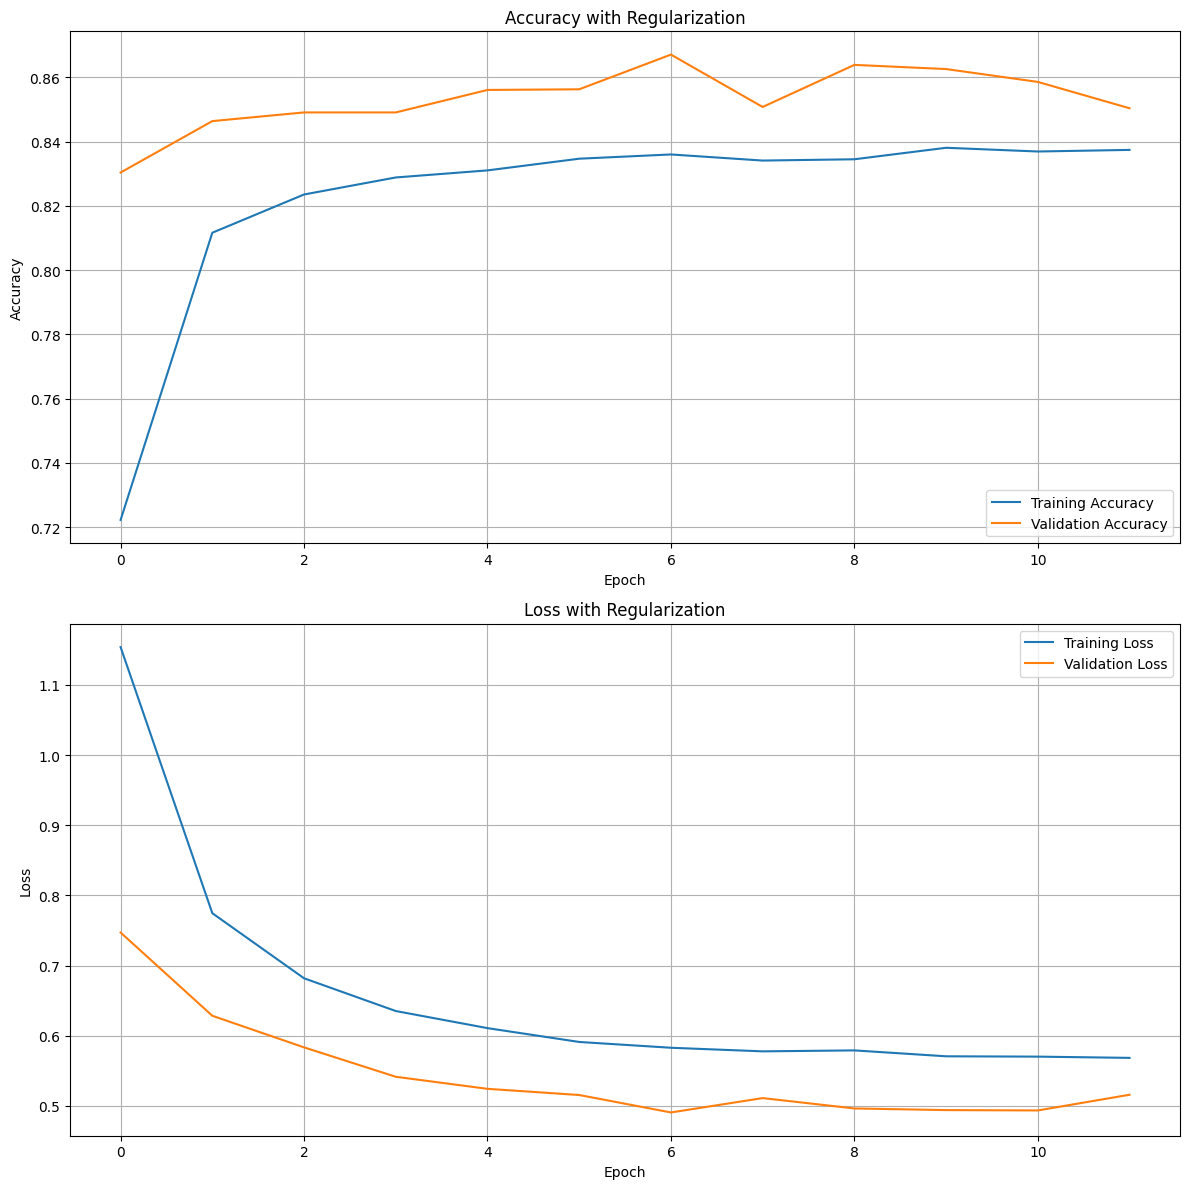


Đánh giá mô hình đã điều chuẩn hóa trên tập test:
313/313 - 0s - 961us/step - accuracy: 0.8559 - loss: 0.5182
Độ chính xác trên tập test: 0.8559


In [12]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 12: Vẽ lại biểu đồ để chứng minh hiệu quả giảm Overfitting
# Bây giờ, chúng ta sẽ vẽ lại hai biểu đồ accuracy và loss cho mô hình mới.
# Bạn sẽ thấy rằng:
# - Khoảng cách giữa đường của training và validation đã thu hẹp đáng kể.
# - Đường validation loss ổn định hơn và không tăng vọt như trước.
# - Đường validation accuracy có thể cao hơn và ổn định hơn ở các epoch cuối.
# Đây là những dấu hiệu rõ ràng cho thấy các kỹ thuật regularization đã hoạt động hiệu quả.

# Tạo một figure chứa 2 biểu đồ con để so sánh trực quan
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Biểu đồ Accuracy
ax1.plot(history_regularized.history['accuracy'], label='Training Accuracy')
ax1.plot(history_regularized.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Accuracy with Regularization')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True)

# Biểu đồ Loss
ax2.plot(history_regularized.history['loss'], label='Training Loss')
ax2.plot(history_regularized.history['val_loss'], label='Validation Loss')
ax2.set_title('Loss with Regularization')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Đánh giá cuối cùng trên tập test
print("\nĐánh giá mô hình đã điều chuẩn hóa trên tập test:")
test_loss, test_acc = regularized_model.evaluate(x_test, y_test, verbose=2)
print(f'Độ chính xác trên tập test: {test_acc:.4f}')

In [13]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 13: Đánh giá cuối cùng của mô hình mới trên tập Test
# Đây là bước cuối cùng trong giai đoạn phát triển mô hình (Develop a Model).
# Sau khi huấn luyện và xác nhận rằng mô hình đã giảm overfitting hiệu quả,
# chúng ta cần một thước đo khách quan về hiệu suất của nó trên dữ liệu hoàn toàn mới.
# Tập test đóng vai trò là dữ liệu "thực tế" này, giúp ta ước tính hiệu suất của mô hình
# khi được triển khai. Kết quả này thường là con số cuối cùng được báo cáo.

print("Đang tiến hành đánh giá cuối cùng trên tập dữ liệu test...")
final_loss, final_acc = regularized_model.evaluate(x_test, y_test, verbose=2)

print("\n--- KẾT QUẢ CUỐI CÙNG ---")
print(f"Mất mát (Loss) trên tập test: {final_loss:.4f}")
print(f"Độ chính xác (Accuracy) trên tập test: {final_acc:.4f}")

# So sánh kết quả này với độ chính xác của mô hình ban đầu (chưa điều chuẩn hóa)
# cho thấy mô hình mới không chỉ ổn định hơn mà còn có thể có hiệu suất tổng quát tốt hơn.

Đang tiến hành đánh giá cuối cùng trên tập dữ liệu test...
313/313 - 0s - 964us/step - accuracy: 0.8559 - loss: 0.5182

--- KẾT QUẢ CUỐI CÙNG ---
Mất mát (Loss) trên tập test: 0.5182
Độ chính xác (Accuracy) trên tập test: 0.8559


In [14]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 14: Lưu mô hình đã huấn luyện
# Sau khi hoàn tất quá trình huấn luyện và đánh giá, chúng ta sẽ lưu lại toàn bộ mô hình.
# Việc này bao gồm kiến trúc, trọng số đã học, và cả cấu hình của optimizer.
# Mô hình được lưu có thể được tải lại sau này để tiếp tục huấn luyện,
# thực hiện dự đoán (inference), hoặc triển khai trong một ứng dụng thực tế.

# Tên file để lưu mô hình (sử dụng định dạng .keras được khuyến nghị)
model_filename = 'ecommerce_fashion_model.keras'

# Lưu mô hình
regularized_model.save(model_filename)

print(f"\nĐã lưu mô hình thành công vào file: '{model_filename}'")

# Bạn có thể tải lại mô hình này bất cứ lúc nào bằng cách sử dụng:
# from tensorflow import keras
# loaded_model = keras.models.load_model('ecommerce_fashion_model.keras')
# loaded_model.summary()


Đã lưu mô hình thành công vào file: 'ecommerce_fashion_model.keras'


In [29]:
# B22CCN476 - Đỗ Ngọc Lâm
# Cell 16 (Phiên bản hoàn chỉnh): Triển khai với chức năng Vẽ và Tải ảnh

# Bước 1: Cài đặt/Cập nhật Gradio
# Chạy lệnh này để đảm bảo bạn có phiên bản Gradio đủ mới để dùng `Blocks`
!pip install -q --upgrade gradio

import gradio as gr
import tensorflow as tf
from tensorflow import keras
import numpy as np
from PIL import Image

print(f"Đã tải Gradio phiên bản: {gr.__version__}")
print(f"Đã tải TensorFlow phiên bản: {tf.__version__}")

# Bước 2: Tải lại mô hình đã được huấn luyện
try:
    model = keras.models.load_model('ecommerce_fashion_model.keras')
    print("\nĐã tải mô hình 'ecommerce_fashion_model.keras' thành công.")
except Exception as e:
    print(f"\nLỗi: Không tìm thấy file mô hình. Vui lòng chạy lại các cell huấn luyện và lưu mô hình trước. Chi tiết lỗi: {e}")
    model = None

# Định nghĩa lại tên các lớp
class_names = ["Áo thun/Áo kiểu", "Quần dài", "Áo chui đầu", "Váy", "Áo khoác",
               "Sandal", "Áo sơ mi", "Giày thể thao", "Túi xách", "Bốt cổ chân"]

# Bước 3: Cập nhật hàm dự đoán để xử lý cả hai loại đầu vào
def predict_fashion_item(image_upload, sketchpad_input):
    if model is None:
        return "Lỗi: Mô hình chưa được tải."

    # Ưu tiên ảnh tải lên, nếu không có thì dùng ảnh vẽ
    if image_upload is not None:
        image = image_upload
        # Ảnh tải lên có thể là ảnh màu, ta cần đảo màu cho phù hợp
        # (Giả định ảnh tải lên là vật thể tối trên nền sáng)
        image = 255 - image
    elif sketchpad_input is not None:
        # Sketchpad trong phiên bản cũ có thể trả về dict
        if isinstance(sketchpad_input, dict):
            image = sketchpad_input['composite']
        else:
            image = sketchpad_input
        # Ảnh vẽ đã được xử lý đảo màu thủ công
        image = 255 - image
    else:
        return "Vui lòng vẽ hoặc tải ảnh lên!"

    # --- Bắt đầu xử lý ảnh ---
    pil_image = Image.fromarray(image.astype(np.uint8))
    pil_image = pil_image.resize((28, 28), Image.LANCZOS)
    pil_image = pil_image.convert('L') # Đảm bảo ảnh là ảnh xám
    image = np.array(pil_image)
    
    # Chuẩn hóa và reshape
    image = image.astype('float32') / 255.0
    image = np.reshape(image, (1, 28, 28))
    
    # Thực hiện dự đoán
    prediction = model.predict(image)[0]
    confidences = {class_names[i]: float(prediction[i]) for i in range(10)}
    
    return confidences

# Bước 4: Xây dựng giao diện tùy chỉnh với `gradio.Blocks`
if model is not None:
    with gr.Blocks() as demo:
        gr.Markdown("# Phân loại Sản phẩm Thời trang 🧥👟👜")
        gr.Markdown("Sử dụng một trong hai cách: **Vẽ trực tiếp** vào khung bên trái, hoặc **Tải ảnh** của bạn lên ở khung bên phải. Sau đó nhấn nút 'Phân loại'.")

        with gr.Row():
            # Input 1: Khung vẽ
            sketchpad = gr.Sketchpad(label="Vẽ vào đây")
            # Input 2: Nút tải ảnh
            image_uploader = gr.Image(label="Hoặc tải ảnh lên đây", type="numpy")
        
        # Nút để thực hiện hành động
        classify_btn = gr.Button("Phân loại", variant="primary")
        
        # Output: Nhãn kết quả
        output_label = gr.Label(num_top_classes=3, label="Kết quả dự đoán")
        
        # Liên kết nút bấm với hàm dự đoán
        classify_btn.click(
            fn=predict_fashion_item,
            inputs=[image_uploader, sketchpad],
            outputs=[output_label]
        )

    # Khởi chạy giao diện
    demo.launch(share=True)


[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Đã tải Gradio phiên bản: 5.49.0
Đã tải TensorFlow phiên bản: 2.20.0

Đã tải mô hình 'ecommerce_fashion_model.keras' thành công.
* Running on local URL:  http://127.0.0.1:7864
* Running on public URL: https://5abc9e1e3860272cf5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [30]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 1: Cài đặt các thư viện cần thiết (Không dùng PyTorch)

# # Thư viện cho xử lý dữ liệu và tạo dataset
# !pip install -q pandas numpy faker

# # Thư viện cho xử lý ngôn ngữ tự nhiên tiếng Việt và Word2Vec
# !pip install -q underthesea gensim

# # Thư viện cho BERT (Transformers sẽ tự động dùng TensorFlow)
# !pip install -q transformers

# # Thư viện cho Machine Learning và Deep Learning
# !pip install -q scikit-learn tensorflow

# # Thư viện cho Lọc cộng tác
# !pip install -q surprise

# # Thư viện để triển khai Web App demo
# !pip install -q gradio

print("Đã cài đặt xong các thư viện cần thiết!")


[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Đã cài đặt xong các thư viện cần thiết!



[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 2 (PHIÊN BẢN CUỐI CÙNG): Tạo bộ dữ liệu thực tế và phức tạp

import pandas as pd
import numpy as np
import random
from faker import Faker
import itertools

# Khởi tạo Faker
fake = Faker('vi_VN')

# --- Định nghĩa các tham số ---
NUM_USERS = 1000
NUM_ITEMS = 500
REVIEWS_PER_USER = 50
YOUR_NAME = "dnlam"
FILENAME = f"itemReview_{YOUR_NAME}.csv"

# --- Tạo danh sách sản phẩm giả ---
item_categories = ["Điện thoại", "Laptop", "Tai nghe", "Quần áo", "Giày dép", "Sách", "Đồng hồ", "Mỹ phẩm"]
items = [f"{random.choice(item_categories)} {fake.word().capitalize()}" for _ in range(NUM_ITEMS)]

# --- KHO CỤM TỪ ĐỂ TẠO REVIEW ---
# Thay vì các từ đơn lẻ, ta dùng các cụm từ có nghĩa để review thực tế hơn
positive_phrases = [
    "sản phẩm rất tốt", "chất lượng tuyệt vời", "giao hàng cực nhanh", "đóng gói cẩn thận",
    "rất đáng tiền", "sẽ ủng hộ shop tiếp", "thiết kế quá đẹp", "máy chạy rất mượt",
    "pin rất trâu", "dịch vụ khách hàng tốt", "mặc vào rất thoải mái", "đúng như mô tả"
]
negative_phrases = [
    "chất lượng khá tệ", "giao hàng quá chậm", "đóng gói sơ sài", "giá hơi cao",
    "không như mong đợi", "dễ bị hỏng", "pin rất yếu", "hỗ trợ khách hàng kém",
    "mô tả sai sự thật", "mặc vào không thoải mái", "có mùi lạ", "bị trầy xước"
]

# --- HÀM TẠO REVIEW BẰNG CÁCH TRỘN CÁC CỤM TỪ ---
def generate_realistic_review(rating):
    num_positive = 0
    num_negative = 0

    if rating == 5:
        num_positive = random.randint(2, 4) # 5 sao: nhiều ý tốt, không có ý xấu
        num_negative = 0
    elif rating == 4:
        num_positive = random.randint(2, 3) # 4 sao: chủ yếu tốt, có thể có 1 ý xấu
        num_negative = random.randint(0, 1)
    elif rating == 3:
        num_positive = random.randint(1, 2) # 3 sao: trộn lẫn tốt xấu
        num_negative = random.randint(1, 2)
    elif rating == 2:
        num_positive = random.randint(0, 1) # 2 sao: chủ yếu xấu, có thể có 1 ý tốt
        num_negative = random.randint(2, 3)
    else: # rating == 1
        num_positive = 0                    # 1 sao: toàn ý xấu
        num_negative = random.randint(2, 4)

    # Lấy ngẫu nhiên các cụm từ từ kho
    pos_choices = random.sample(positive_phrases, k=num_positive) if num_positive > 0 else []
    neg_choices = random.sample(negative_phrases, k=num_negative) if num_negative > 0 else []

    # Trộn các ý lại với nhau
    review_parts = pos_choices + neg_choices
    if not review_parts: # Trường hợp hiếm không chọn được gì
        return "Sản phẩm bình thường."
        
    random.shuffle(review_parts)
    
    # Nối các phần thành một câu hoàn chỉnh
    review = ", ".join(review_parts) + "."
    return review.capitalize()


# --- Tạo dữ liệu ---
print("Đang tạo bộ dữ liệu mới, vui lòng chờ...")
data = []
for user_id in range(NUM_USERS):
    reviewed_items = np.random.choice(range(NUM_ITEMS), REVIEWS_PER_USER, replace=False)
    for item_id in reviewed_items:
        rating = np.random.choice([1, 2, 3, 4, 5], p=[0.05, 0.1, 0.2, 0.35, 0.3])
        review_text = generate_realistic_review(rating)
        data.append([user_id, item_id, items[item_id], rating, review_text])

# --- Tạo DataFrame và lưu file CSV ---
df = pd.DataFrame(data, columns=['user_id', 'item_id', 'item_name', 'rating', 'review'])
df.to_csv(FILENAME, index=False)

print(f"Đã tạo thành công file '{FILENAME}' với {len(df)} dòng dữ liệu phức tạp hơn.")
print("\nVí dụ một vài bình luận mới được tạo ra:")
print(df.sample(5)[['rating', 'review']].to_string(index=False))

Đang tạo bộ dữ liệu mới, vui lòng chờ...
Đã tạo thành công file 'itemReview_dnlam.csv' với 50000 dòng dữ liệu phức tạp hơn.

Ví dụ một vài bình luận mới được tạo ra:
 rating                                                                    review
      4                                 Mặc vào rất thoải mái, đóng gói cẩn thận.
      4                     Đúng như mô tả, pin rất trâu, dịch vụ khách hàng tốt.
      5   Mặc vào rất thoải mái, máy chạy rất mượt, pin rất trâu, đúng như mô tả.
      4 Mặc vào rất thoải mái, sẽ ủng hộ shop tiếp, có mùi lạ, máy chạy rất mượt.
      5     Đúng như mô tả, sản phẩm rất tốt, sẽ ủng hộ shop tiếp, rất đáng tiền.


In [54]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 3: Tải dữ liệu và Tiền xử lý (Stopword, Normalization)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from underthesea import word_tokenize

# Tải dữ liệu
FILENAME = f"itemReview_{YOUR_NAME}.csv"
df = pd.read_csv(FILENAME)

# --- d. Chuẩn hóa Rating ---
scaler = MinMaxScaler()
df['rating_normalized'] = scaler.fit_transform(df[['rating']])

# --- c. Xử lý Stopword tiếng Việt ---
# Danh sách stop word tiếng Việt
vietnamese_stopwords = [
    'và', 'của', 'là', 'cho', 'có', 'không', 'được', 'với', 'như', 'đã', 'thì', 'mà', 'tôi', 'bạn',
    'anh', 'chị', 'em', 'đây', 'đó', 'này', 'kia', 'khi', 'để', 'một', 'hai', 'ba', 'bốn', 'năm',
    'sáu', 'bảy', 'tám', 'chín', 'mười', 'rất', 'quá', 'cũng', 'nhưng', 'tại', 'vì', 'sao', 'nên'
]

def remove_stopwords(text):
    words = word_tokenize(text.lower())
    return " ".join([word for word in words if word not in vietnamese_stopwords])

df['review_cleaned'] = df['review'].apply(remove_stopwords)

print("Dữ liệu sau khi tiền xử lý:")
df.head()

Dữ liệu sau khi tiền xử lý:


,user_id,item_id,item_name,rating,review,rating_normalized,review_cleaned
0,0,73,Giày dép Để,3,"Sản phẩm rất tốt, hỗ trợ khách hàng kém, sẽ ủn...",0.50,"sản phẩm tốt , hỗ trợ khách hàng kém , sẽ ủng ..."
1,0,188,Sách Về,4,"Sản phẩm rất tốt, đúng như mô tả.",0.75,"sản phẩm tốt , đúng mô tả ."
2,0,105,Giày dép Vậy,5,"Đóng gói cẩn thận, máy chạy rất mượt, chất lượ...",1.00,"đóng gói cẩn thận , máy chạy mượt , chất lượng..."
3,0,239,Mỹ phẩm Đi,3,"Chất lượng khá tệ, mặc vào không thoải mái, ch...",0.50,"chất lượng khá tệ , mặc vào thoải mái , chất l..."
4,0,377,Đồng hồ Theo,4,"Hỗ trợ khách hàng kém, chất lượng tuyệt vời, d...",0.75,"hỗ trợ khách hàng kém , chất lượng tuyệt vời ,..."


In [55]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 4: Biểu diễn văn bản bằng Word2Vec

from gensim.models import Word2Vec

# Chuẩn bị dữ liệu cho Word2Vec
sentences = [text.split() for text in df['review_cleaned']]

# Huấn luyện mô hình Word2Vec
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)
w2v_model.save("word2vec.model")

print("Đã huấn luyện và lưu mô hình Word2Vec.")
print("Ví dụ vector của từ 'sản phẩm':")
# Lưu ý: từ 'sản phẩm' bị tách thành 'sản', 'phẩm' nên ta lấy vector của 'sản'
print(w2v_model.wv['sản'])

Đã huấn luyện và lưu mô hình Word2Vec.
Ví dụ vector của từ 'sản phẩm':
[ 0.27809     0.85210526  1.4309531   0.59429854 -0.84691554  0.73952365
  1.074613    0.06736241  1.464634   -0.38692454 -0.01617439 -0.036943
  0.39458263 -1.1178643   0.66118306 -0.62329006  0.44785136 -0.76520216
  0.8043539  -0.33536685  1.2099249  -0.29924008 -0.7034287   0.28294322
 -0.85494787 -0.1497462   0.71893984 -0.12009797  0.28516632 -1.8313053
 -0.1028586  -0.6607718  -0.17404337  0.26012135  0.3606503  -1.4745657
  0.5989338   1.098774   -0.2089444   1.9526124  -1.1428477  -0.20479369
  0.63393533  0.49287283 -1.669797   -1.7832553   2.1259348   0.3470151
 -0.36951965  0.3474896  -0.22809535  0.0910199   0.37462685  1.3934604
 -0.7599434   1.6070344   1.2261689  -0.42397973 -1.4492438   0.70734006
 -0.1848837  -1.6545744   0.8068335  -0.51671654 -2.1245966   0.16012877
 -1.3971809  -0.4338069   0.21520162 -1.4141321   0.36128467 -0.9785641
  0.7359782   0.35013112 -0.10158984  1.5519911   0.7689767 

In [56]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 5: Biểu diễn văn bản bằng PhoBERT (sử dụng TensorFlow)

import tensorflow as tf
from transformers import TFAutoModel, AutoTokenizer

# Tải PhoBERT tokenizer và model phiên bản TensorFlow
# Thư viện transformers sẽ tự động tải các trọng số tương thích với TF
phobert_tf = TFAutoModel.from_pretrained("vinai/phobert-base")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

# Ví dụ cách dùng PhoBERT để lấy vector cho một câu
example_sentence = df['review_cleaned'].iloc[0]

# Tokenize câu và trả về dưới dạng TensorFlow tensors
input_dict = tokenizer(example_sentence, return_tensors='tf')

# Lấy embedding từ PhoBERT
features = phobert_tf(input_dict)

# Lấy vector biểu diễn của cả câu (từ embedding của token [CLS] - token đầu tiên)
sentence_embedding = features.last_hidden_state[:, 0, :].numpy()

print(f"Câu bình luận: '{example_sentence}'")
print(f"Kích thước vector biểu diễn của câu (dùng PhoBERT-TF): {sentence_embedding.shape}")

Some layers from the model checkpoint at vinai/phobert-base were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at vinai/phobert-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spac

Câu bình luận: 'sản phẩm tốt , hỗ trợ khách hàng kém , sẽ ủng hộ shop tiếp .'
Kích thước vector biểu diễn của câu (dùng PhoBERT-TF): (1, 768)


In [57]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 6: Xây dựng mô hình Lọc cộng tác với Surprise

from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split as surprise_split
from surprise import accuracy

# Chuẩn bị dữ liệu cho thư viện Surprise
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df[['user_id', 'item_id', 'rating']], reader)

# Chia tập train/test
trainset, testset = surprise_split(data, test_size=0.2)

# Sử dụng thuật toán SVD
model_cf = SVD()
model_cf.fit(trainset)

# Đánh giá mô hình
predictions = model_cf.test(testset)
print(f"Độ lỗi RMSE của mô hình Lọc cộng tác: {accuracy.rmse(predictions):.4f}")

# Ví dụ dự đoán
user_id_example = 10
item_id_example = 20
predicted_rating = model_cf.predict(user_id_example, item_id_example)
print(f"Dự đoán rating của User {user_id_example} cho Item {item_id_example} là: {predicted_rating.est:.2f} sao")

RMSE: 1.1740
Độ lỗi RMSE của mô hình Lọc cộng tác: 1.1740
Dự đoán rating của User 10 cho Item 20 là: 3.66 sao


In [58]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 7: Chuẩn bị dữ liệu cho các mô hình Deep Learning

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# --- Chuẩn bị dữ liệu ---
texts = df['review_cleaned'].values
labels = df['rating'].values - 1 

# Tokenize và padding
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
max_len = 50
X = pad_sequences(sequences, maxlen=max_len)
y = to_categorical(labels, num_classes=5)

# Chia tập train, validation, test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Kích thước tập train: {X_train.shape}")
print(f"Kích thước tập validation: {X_val.shape}")
print(f"Kích thước tập test: {X_test.shape}")

Kích thước tập train: (35000, 50)
Kích thước tập validation: (7500, 50)
Kích thước tập test: (7500, 50)


In [59]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 8: Xây dựng và Huấn luyện 3 mô hình (CNN, RNN, LSTM) - Hiển thị lịch sử training

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# --- Tham số chung ---
VOCAB_SIZE = 10000
EMBEDDING_DIM = 100
MAX_LEN = 50
NUM_CLASSES = 5

# --- 1. Mô hình CNN ---
model_cnn = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(10, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])
model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("--- Bắt đầu huấn luyện mô hình CNN ---")
history_cnn = model_cnn.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), batch_size=128, verbose=1) # THAY ĐỔI
print("Đã huấn luyện xong mô hình CNN.\n")

# --- 2. Mô hình RNN ---
model_rnn = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(128),
    Dense(NUM_CLASSES, activation='softmax')
])
model_rnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("--- Bắt đầu huấn luyện mô hình RNN ---")
history_rnn = model_rnn.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), batch_size=128, verbose=1) # THAY ĐỔI
print("Đã huấn luyện xong mô hình RNN.\n")

# --- 3. Mô hình LSTM (bị Overfitting) ---
model_lstm_overfit = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])
model_lstm_overfit.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("--- Bắt đầu huấn luyện mô hình LSTM (bản Overfitting) ---")
history_lstm_overfit = model_lstm_overfit.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), batch_size=128, verbose=1) # THAY ĐỔI
print("Đã huấn luyện xong mô hình LSTM (bản Overfitting).\n")

--- Bắt đầu huấn luyện mô hình CNN ---
Epoch 1/10


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5853 - loss: 0.8297 - val_accuracy: 0.6420 - val_loss: 0.6572
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6447 - loss: 0.6422 - val_accuracy: 0.6451 - val_loss: 0.6313
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6524 - loss: 0.6202 - val_accuracy: 0.6435 - val_loss: 0.6166
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6581 - loss: 0.6072 - val_accuracy: 0.6461 - val_loss: 0.6089
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6629 - loss: 0.5985 - val_accuracy: 0.6363 - val_loss: 0.6196
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6671 - loss: 0.5929 - val_accuracy: 0.6495 - val_loss: 0.6454
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6699 - loss: 0.5899 - val_accuracy: 0.6592 - val_loss: 0.6034
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6697 - loss: 0.5836 - val_accuracy: 0.655

--- Biểu đồ huấn luyện của mô hình CNN ---


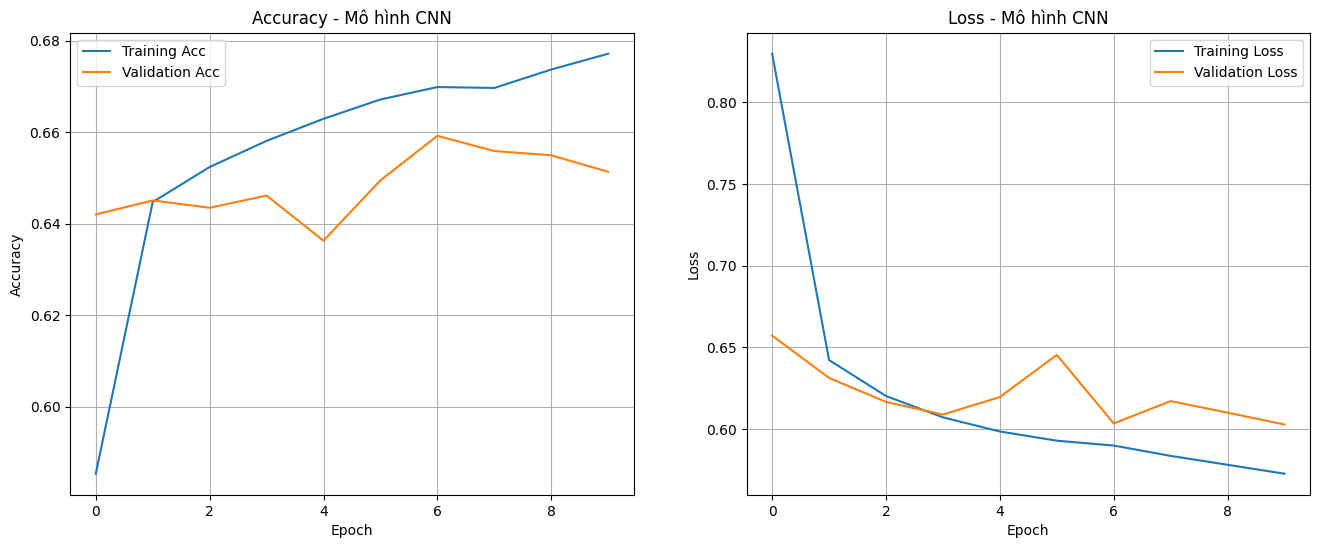


--- Biểu đồ huấn luyện của mô hình RNN ---


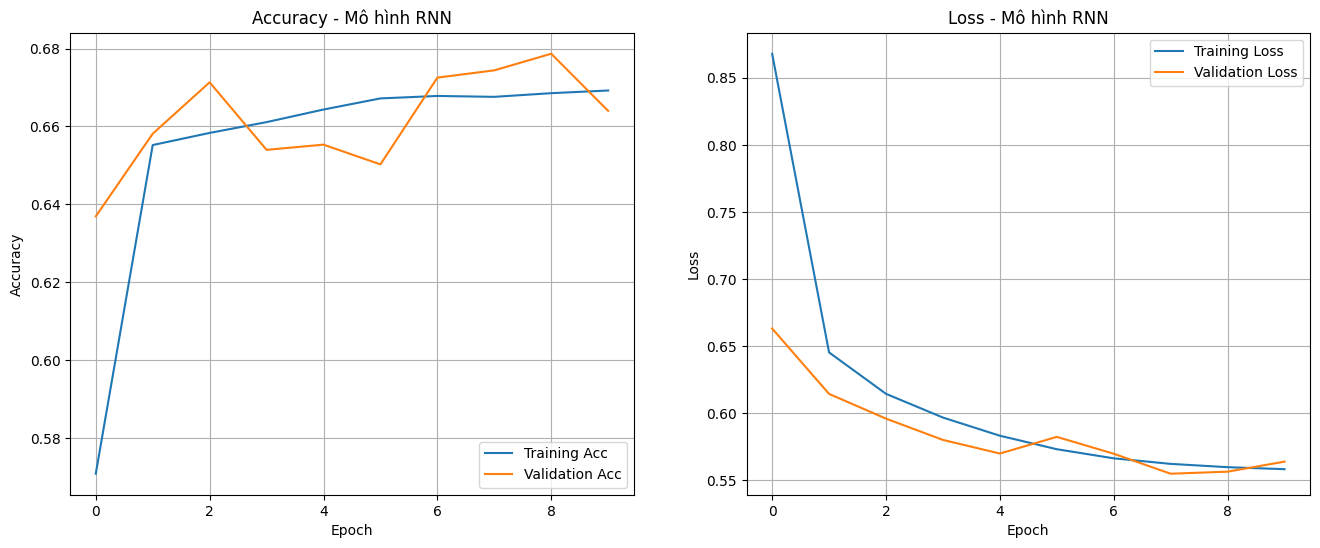


--- Biểu đồ huấn luyện của mô hình LSTM (bản Overfitting) ---


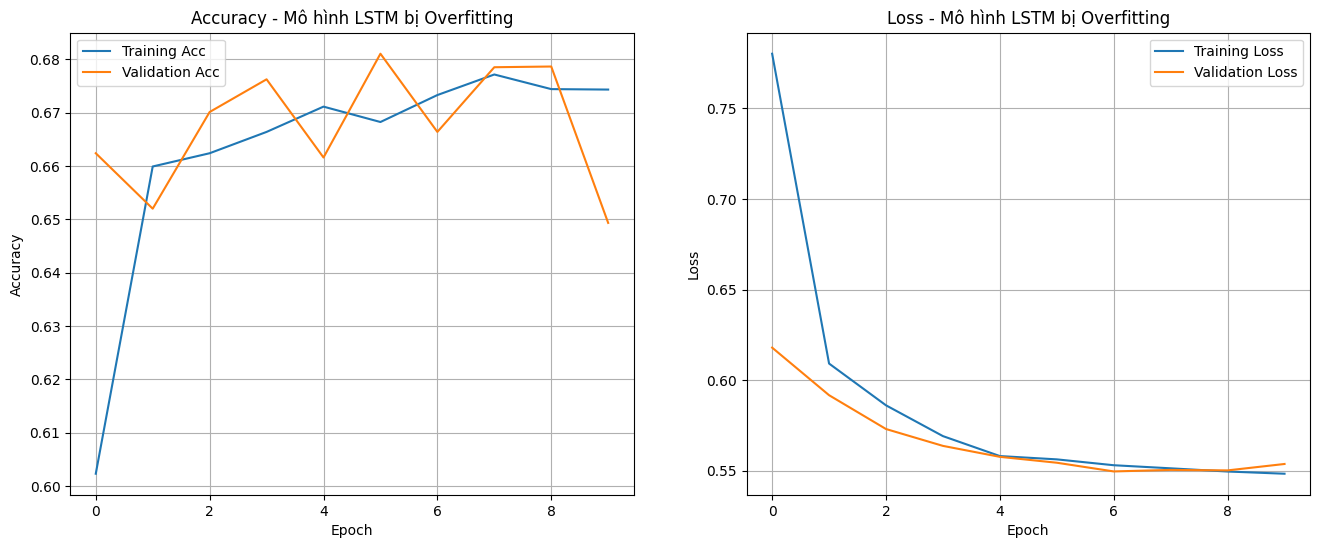

In [60]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 9: Phân tích Overfitting và trực quan hóa lịch sử training của cả 3 mô hình

import matplotlib.pyplot as plt

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot Accuracy
    ax1.plot(history.history['accuracy'], label='Training Acc')
    ax1.plot(history.history['val_accuracy'], label='Validation Acc')
    ax1.set_title(f'Accuracy - {title}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Plot Loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'Loss - {title}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.show()

# --- Vẽ biểu đồ cho cả 3 mô hình ---
print("--- Biểu đồ huấn luyện của mô hình CNN ---")
plot_history(history_cnn, "Mô hình CNN")

print("\n--- Biểu đồ huấn luyện của mô hình RNN ---")
plot_history(history_rnn, "Mô hình RNN")

print("\n--- Biểu đồ huấn luyện của mô hình LSTM (bản Overfitting) ---")
plot_history(history_lstm_overfit, "Mô hình LSTM bị Overfitting")

In [63]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 10: Cải thiện và Huấn luyện cả 3 mô hình

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# --- Callback chung cho cả 3 mô hình ---
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# --- 1. Cải thiện mô hình CNN ---
model_cnn_improved = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu', kernel_regularizer=l2(0.001)),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(10, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])
model_cnn_improved.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("--- Bắt đầu huấn luyện mô hình CNN đã cải thiện ---")
history_cnn_improved = model_cnn_improved.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=128, callbacks=[early_stopping], verbose=1)
print("Đã huấn luyện xong mô hình CNN đã cải thiện.\n")

# --- 2. Cải thiện mô hình RNN ---
model_rnn_improved = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    SimpleRNN(128, kernel_regularizer=l2(0.001), dropout=0.2, recurrent_dropout=0.2),
    Dense(NUM_CLASSES, activation='softmax')
])
model_rnn_improved.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("--- Bắt đầu huấn luyện mô hình RNN đã cải thiện ---")
history_rnn_improved = model_rnn_improved.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=128, callbacks=[early_stopping], verbose=1)
print("Đã huấn luyện xong mô hình RNN đã cải thiện.\n")

# --- 3. Cải thiện mô hình LSTM ---
model_lstm_improved = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(128, kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])
model_lstm_improved.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("--- Bắt đầu huấn luyện mô hình LSTM đã cải thiện ---")
history_lstm_improved = model_lstm_improved.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=128, callbacks=[early_stopping], verbose=1)
print("Đã huấn luyện xong mô hình LSTM đã cải thiện.\n")

--- Bắt đầu huấn luyện mô hình CNN đã cải thiện ---
Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5405 - loss: 1.0316 - val_accuracy: 0.6308 - val_loss: 0.7593
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6172 - loss: 0.7757 - val_accuracy: 0.6316 - val_loss: 0.7165
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6223 - loss: 0.7438 - val_accuracy: 0.6440 - val_loss: 0.6959
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6259 - loss: 0.7305 - val_accuracy: 0.6505 - val_loss: 0.6872
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6313 - loss: 0.7223 - val_accuracy: 0.6419 - val_loss: 0.6883
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6280 - loss: 0.7189 - val_accuracy: 0.6493 - val_loss: 0.6824
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6354 - loss: 0.7121 - val_accuracy: 0.6455 - val_loss: 0.6794
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 15

--- Biểu đồ huấn luyện của mô hình CNN (Đã cải thiện) ---


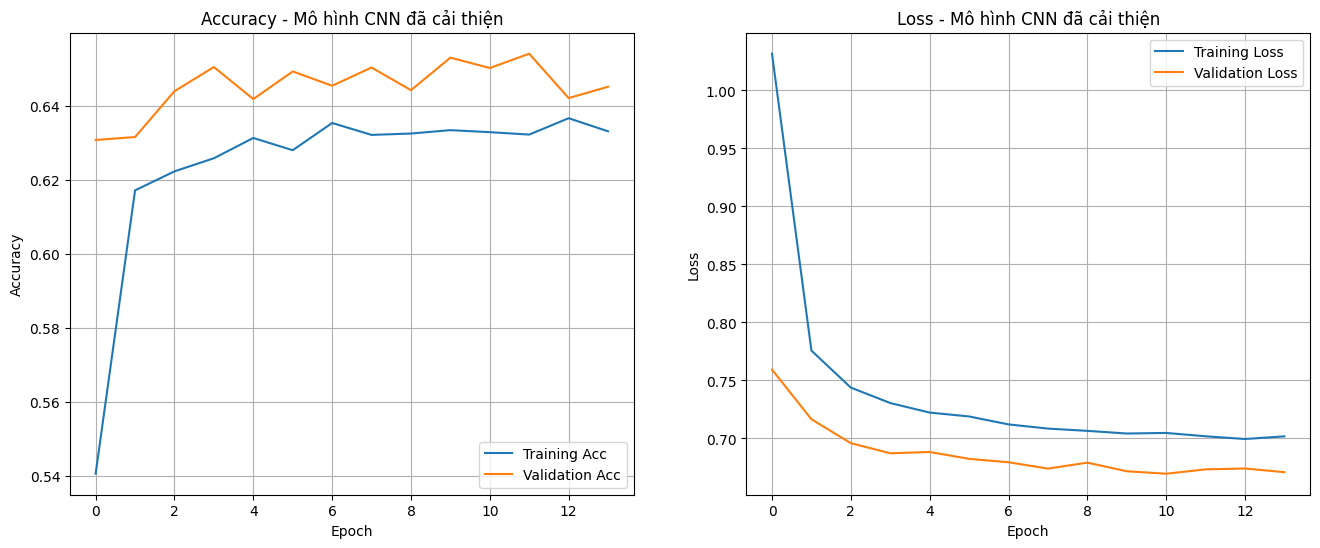


--- Biểu đồ huấn luyện của mô hình RNN (Đã cải thiện) ---


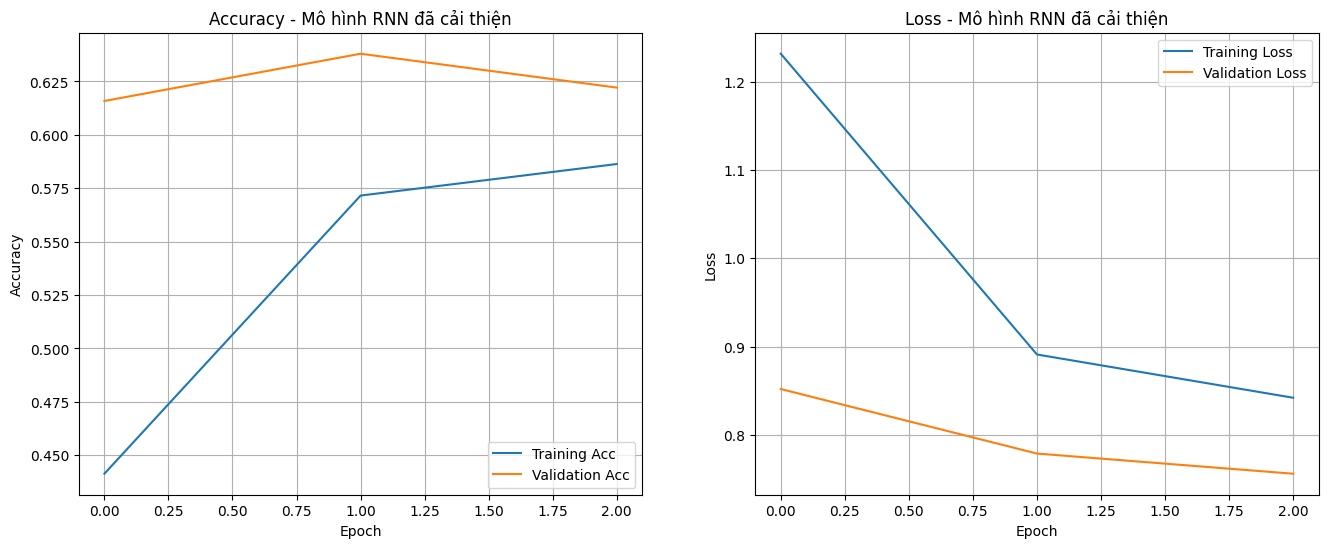


--- Biểu đồ huấn luyện của mô hình LSTM (Đã cải thiện) ---


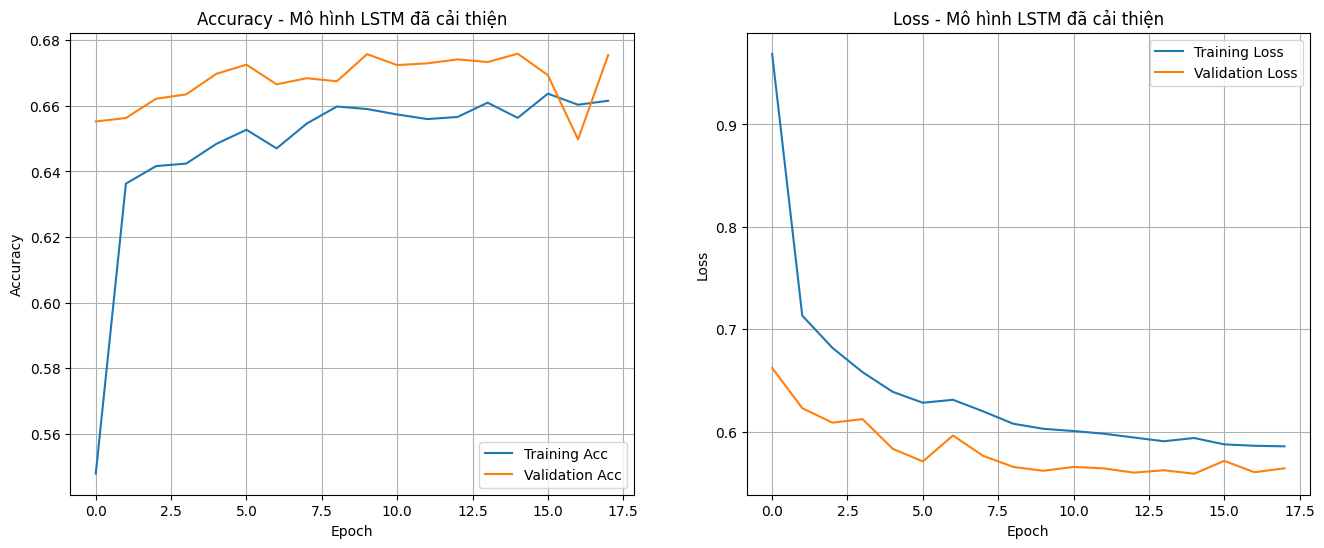

In [64]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 11: Trực quan hóa chi tiết từng mô hình đã cải thiện

# Định nghĩa lại hàm vẽ biểu đồ nếu cần
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot Accuracy
    ax1.plot(history.history['accuracy'], label='Training Acc')
    ax1.plot(history.history['val_accuracy'], label='Validation Acc')
    ax1.set_title(f'Accuracy - {title}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Plot Loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'Loss - {title}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.show()

# --- Vẽ biểu đồ chi tiết cho từng mô hình đã cải thiện ---
print("--- Biểu đồ huấn luyện của mô hình CNN (Đã cải thiện) ---")
plot_history(history_cnn_improved, "Mô hình CNN đã cải thiện")

print("\n--- Biểu đồ huấn luyện của mô hình RNN (Đã cải thiện) ---")
plot_history(history_rnn_improved, "Mô hình RNN đã cải thiện")

print("\n--- Biểu đồ huấn luyện của mô hình LSTM (Đã cải thiện) ---")
plot_history(history_lstm_improved, "Mô hình LSTM đã cải thiện")

In [66]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 11.h: Đánh giá và so sánh các mô hình để chọn ra mô hình tốt nhất

# --- Đánh giá hiệu suất cuối cùng trên tập Test ---
print("--- Đang đánh giá hiệu suất cuối cùng của các mô hình trên tập Test ---")
loss_cnn, acc_cnn = model_cnn_improved.evaluate(X_test, y_test, verbose=0)
loss_rnn, acc_rnn = model_rnn_improved.evaluate(X_test, y_test, verbose=0)
loss_lstm, acc_lstm = model_lstm_improved.evaluate(X_test, y_test, verbose=0)

# --- In kết quả ra bảng so sánh ---
print("\n" + "="*50)
print("KẾT QUẢ SO SÁNH CUỐI CÙNG TRÊN TẬP TEST")
print("="*50)
print(f"| {'Mô hình':<15} | {'Loss':<15} | {'Accuracy':<15} |")
print("-"*50)
print(f"| {'CNN Improved':<15} | {loss_cnn:<15.4f} | {acc_cnn:<15.4f} |")
print(f"| {'RNN Improved':<15} | {loss_rnn:<15.4f} | {acc_rnn:<15.4f} |")
print(f"| {'LSTM Improved':<15} | {loss_lstm:<15.4f} | {acc_lstm:<15.4f} |")
print("="*50)

--- Đang đánh giá hiệu suất cuối cùng của các mô hình trên tập Test ---

KẾT QUẢ SO SÁNH CUỐI CÙNG TRÊN TẬP TEST
| Mô hình         | Loss            | Accuracy        |
--------------------------------------------------
| CNN Improved    | 0.6783          | 0.6480          |
| RNN Improved    | 0.8644          | 0.6008          |
| LSTM Improved   | 0.5654          | 0.6701          |


In [65]:
# B22DCCN476 - Đỗ Ngọc Lâm
# Cell 12: Triển khai mô hình tốt nhất (LSTM) lên Web App

import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- Chọn mô hình tốt nhất để triển khai ---
# Dựa trên kết quả đánh giá, mô hình LSTM đã cải thiện là lựa chọn tốt nhất.
deploy_model = model_lstm_improved

# --- Định nghĩa lại các hàm và biến cần thiết cho việc xử lý input ---
# (Tokenizer đã được huấn luyện ở Cell 7, stopwords đã có ở Cell 3)
def predict_review(text):
    # 1. Tiền xử lý input giống hệt như lúc training
    cleaned_text = remove_stopwords(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded_sequence = pad_sequences(sequence, maxlen=MAX_LEN)
    
    # 2. Dự đoán bằng mô hình đã chọn
    prediction = deploy_model.predict(padded_sequence)[0]
    
    # 3. Định dạng lại output cho dễ hiểu
    # Chuyển mảng xác suất thành dictionary với nhãn là số sao
    confidences = {f"{i+1} sao": float(prediction[i]) for i in range(NUM_CLASSES)}
    
    return confidences

# --- Tạo giao diện Web với Gradio ---
interface = gr.Interface(
    fn=predict_review,
    inputs=gr.Textbox(lines=5, label="Bình luận sản phẩm", placeholder="Nhập bình luận của bạn ở đây..."),
    outputs=gr.Label(num_top_classes=5, label="Kết quả dự đoán (Rating)"),
    title="🤖 Hệ thống Phân tích Cảm xúc Bình luận",
    description="Đây là giao diện cho mô hình LSTM đã được huấn luyện. Hãy nhập một bình luận về sản phẩm để dự đoán xem nó tương ứng với bao nhiêu sao.",
    examples=[
        ["sản phẩm rất tốt, giao hàng cực nhanh, sẽ ủng hộ shop tiếp"],
        ["chất lượng tuyệt vời nhưng giao hàng quá chậm"],
        ["máy chạy rất mượt nhưng pin rất yếu"],
        ["chất lượng khá tệ, không như mong đợi"]
    ]
)

# --- Khởi chạy giao diện ---
# share=True sẽ tạo một đường link public tạm thời để bạn có thể chia sẻ
interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7865
* Running on public URL: https://7f49293ed3ea1c7b48.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
